# Predictive Modeling for Silica Concentration in Mining Flotation Process
##### DataSource: <https://www.kaggle.com/datasets/edumagalhaes/quality-prediction-in-a-mining-process>
## Project Overview:
This study aims to develop a machine learning model to predict the percentage of silica in the final product of a mining flotation process. The project utilizes data from Kaggle's "Quality Prediction in a Mining Process" dataset.

## Key Objectives:
- Enhance process reliability
- Minimize environmental impact by reducing wastewater
- Optimize operational costs by decreasing reliance on laboratory testing

## Primary Findings:
- **Model Selection:** Random Forest algorithm chosen for deployment
- **Model Performance:**
  - Root Mean Square Error (RMSE): 0.185
  - Coefficient of Determination (R²): 0.853R²): 0.853 - R2: 0.853

### Import  library 


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


### Load Data

In [2]:
data = pd.read_csv('../Datasets/MiningProcess_Flotation_Plant_Database.csv')


In [3]:
data.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date                          737453 non-null  object
 1   % Iron Feed                   737453 non-null  object
 2   % Silica Feed                 737453 non-null  object
 3   Starch Flow                   737453 non-null  object
 4   Amina Flow                    737453 non-null  object
 5   Ore Pulp Flow                 737453 non-null  object
 6   Ore Pulp pH                   737453 non-null  object
 7   Ore Pulp Density              737453 non-null  object
 8   Flotation Column 01 Air Flow  737453 non-null  object
 9   Flotation Column 02 Air Flow  737453 non-null  object
 10  Flotation Column 03 Air Flow  737453 non-null  object
 11  Flotation Column 04 Air Flow  737453 non-null  object
 12  Flotation Column 05 Air Flow  737453 non-null  object
 13 

In [5]:
TIMESTAMP_COL = 'date'
TARGET_VARIABLE = '% Silica Concentrate'
data[TIMESTAMP_COL] = pd.to_datetime(data[TIMESTAMP_COL])

columnas_objeto = data.select_dtypes(include=['object']).columns

print("Limpiando datos: Reemplazando comas por puntos y convirtiendo a números...")
for col in columnas_objeto:
    # errors='coerce' transforma cualquier texto extraño que no sea un
    # número en NaN — así cualquier fila corrupta se hace visible en el
    # chequeo de missingness del Paso E, en vez de fallar en silencio.
    data[col] = pd.to_numeric(data[col].astype(str).str.replace(',', '.'), errors='coerce')

print("Limpieza completada.\n")
print("Tipos de datos tras limpieza:")
print(data.dtypes.value_counts())

# data=data.drop('date',axis=1)

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

Limpiando datos: Reemplazando comas por puntos y convirtiendo a números...
Limpieza completada.

Tipos de datos tras limpieza:
float64           23
datetime64[ns]     1
Name: count, dtype: int64


### Clean Data

In [6]:
data.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


### Data exploration

In [7]:
print(data.isnull().sum())


date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64


In [8]:
data.describe()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,...,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000
mean,2017-06-16 03:27:22.656549376,56.294739,14.651716,2869.140569,488.144697,397.578372,9.767639,1.680380,280.151856,277.159965,...,290.754856,520.244823,522.649555,531.352662,420.320973,425.251706,429.941018,421.021231,65.050068,2.326763
min,2017-03-10 01:00:00,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,...,185.962000,149.218000,210.752000,126.255000,162.201000,166.991000,155.841000,175.349000,62.050000,0.600000
25%,2017-05-04 23:00:00,52.670000,8.940000,2076.320000,431.796000,394.264000,9.527360,1.647310,250.281000,250.457000,...,256.302000,416.978000,441.883000,411.325000,356.679000,357.653000,358.497000,356.772000,64.370000,1.440000
50%,2017-06-16 15:00:00,56.080000,13.850000,3018.430000,504.393000,399.249000,9.798100,1.697600,299.344000,296.223000,...,299.011000,491.878000,495.956000,494.318000,411.974000,408.773000,424.664575,411.065000,65.210000,2.000000
75%,2017-07-29 07:00:00,59.720000,19.600000,3727.730000,553.257000,402.968000,10.038000,1.728330,300.149000,300.690000,...,301.904000,594.114000,595.464000,601.249000,485.549000,484.329000,492.684000,476.465000,65.860000,3.010000
max,2017-09-09 23:00:00,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,...,371.593000,862.274000,828.919000,886.822000,680.359000,675.644000,698.861000,659.902000,68.010000,5.530000
std,NaN,5.157744,6.807439,1215.203734,91.230534,9.699785,0.387007,0.069249,29.621288,30.149357,...,28.670105,131.014924,128.165050,150.842164,91.794432,84.535822,89.862225,84.891491,1.118645,1.125554


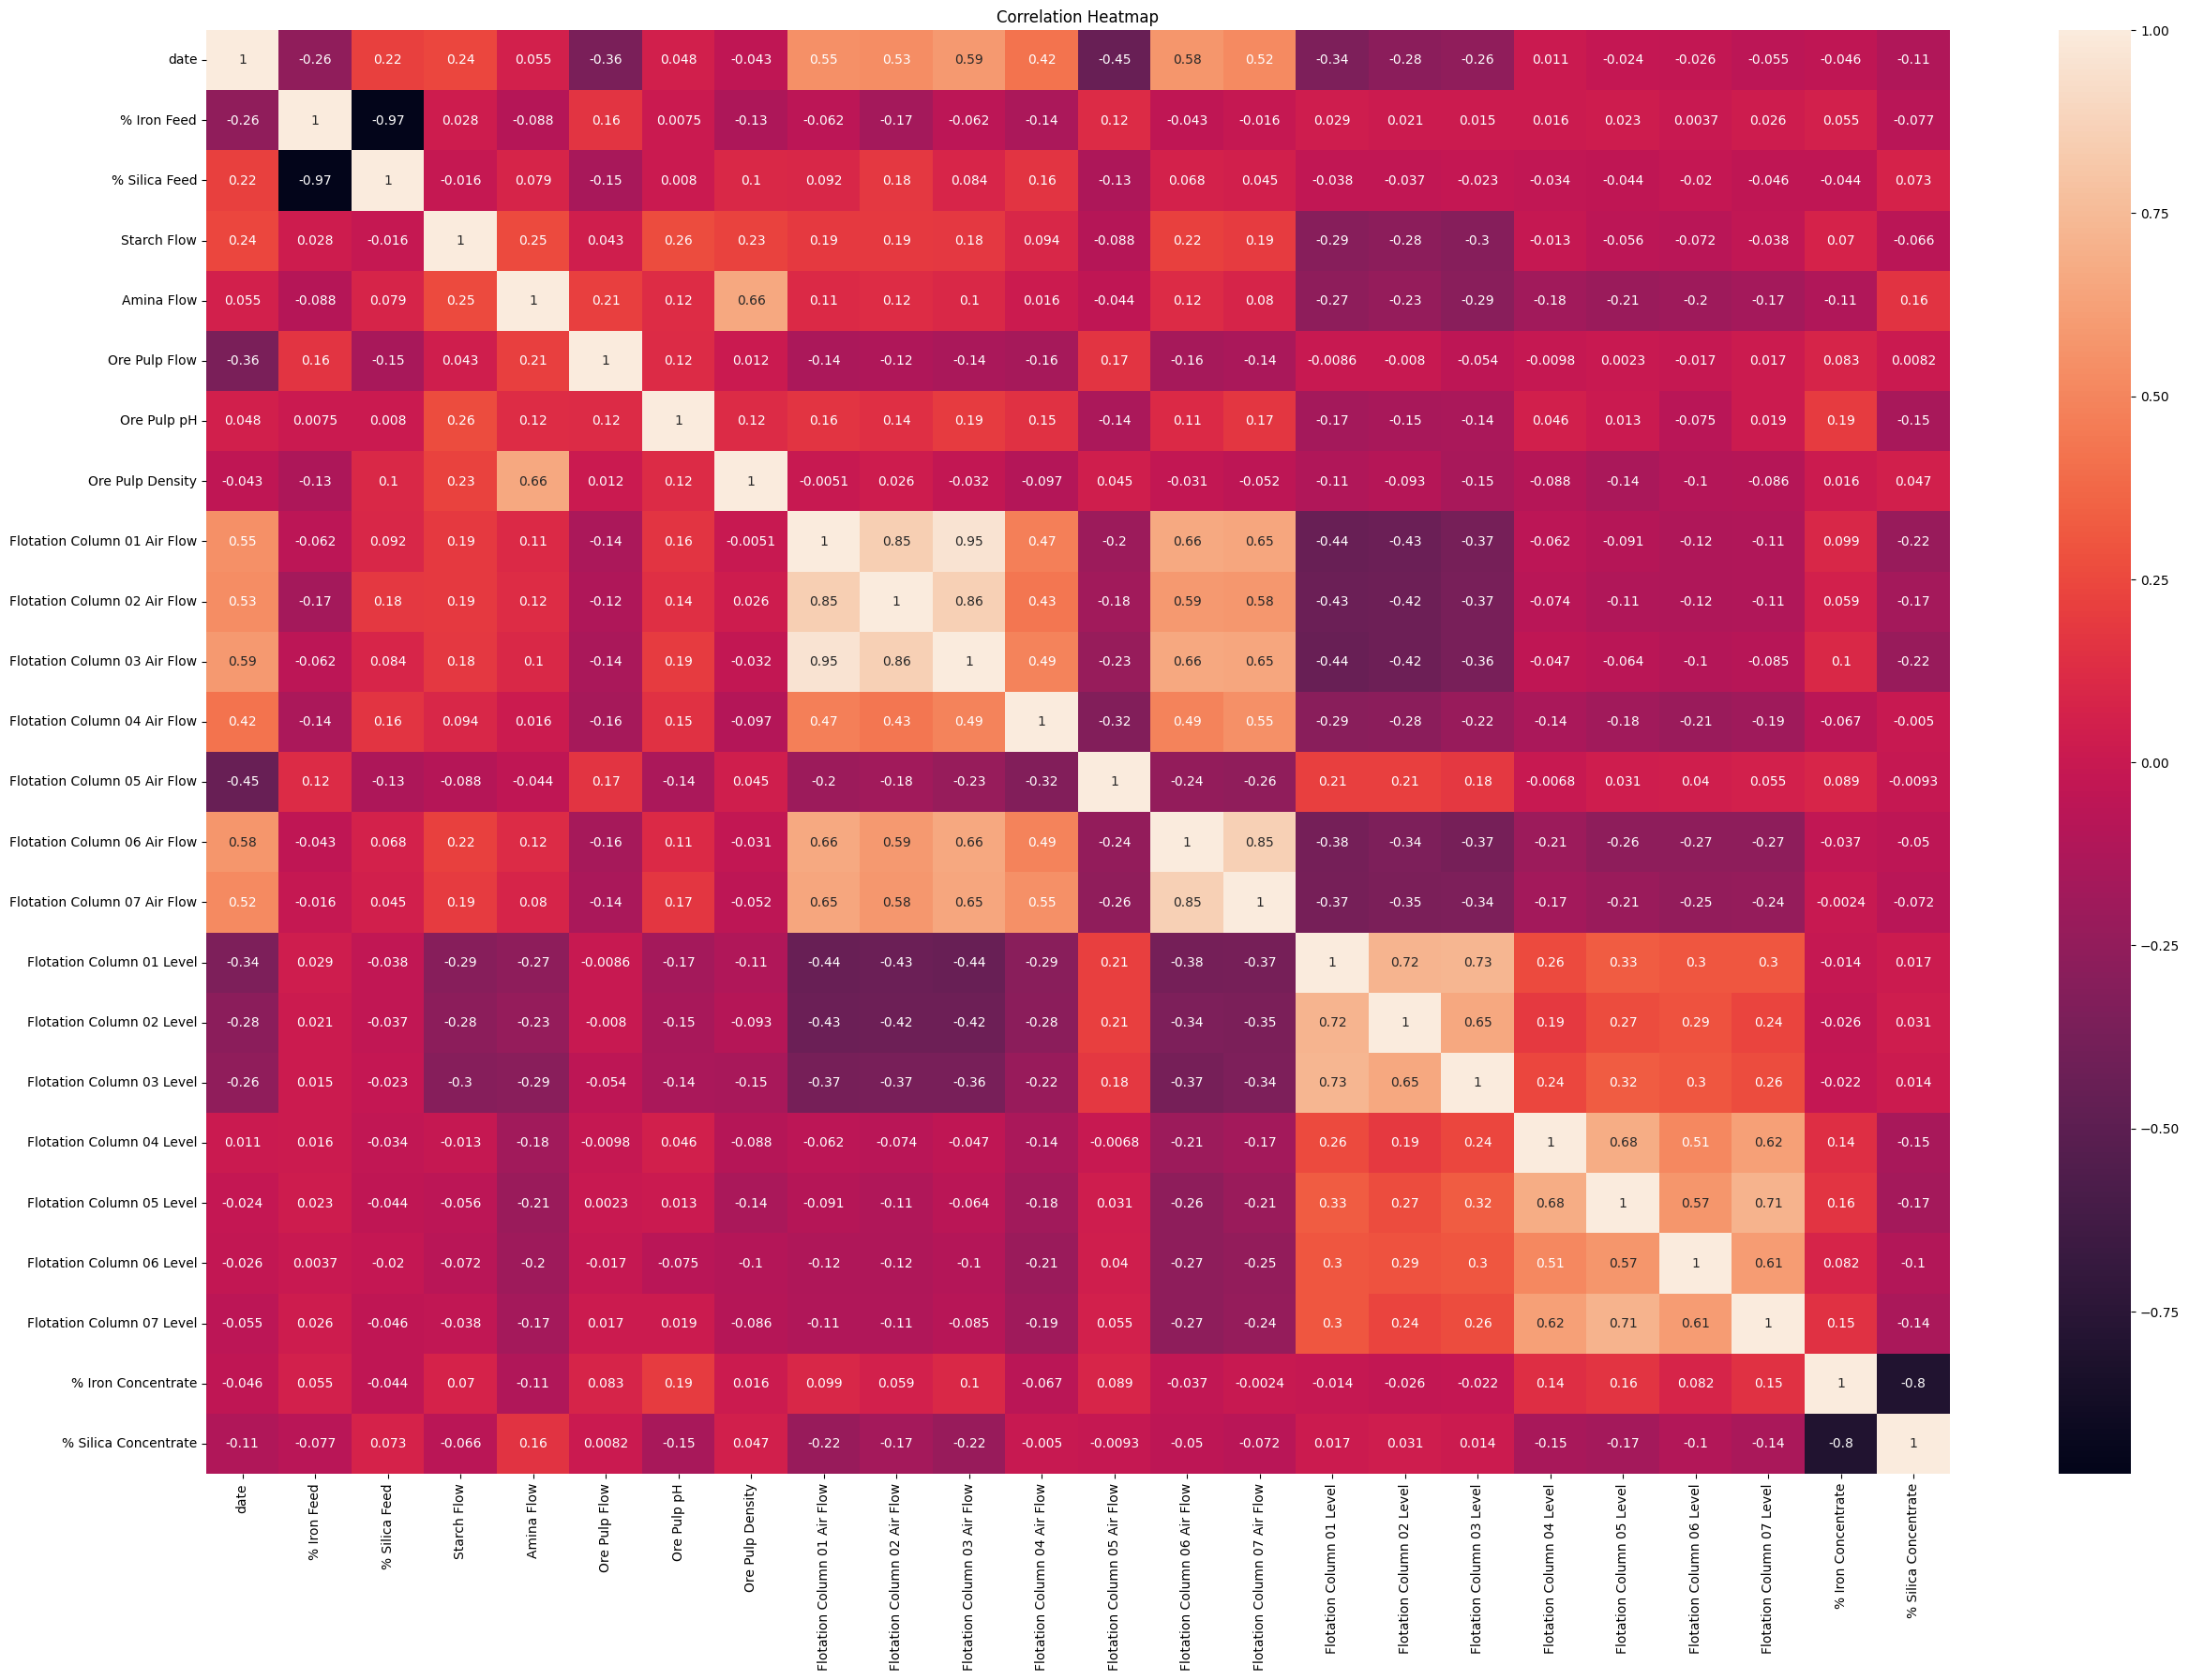

In [9]:
#data corrleation

plt.figure(figsize=(30,20))
sns.heatmap(data.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

##### From Correlation Matrix, possible features relating with label are as follows:
    
- iron concentrate
- amina flow
- ore pulp flow
- ore pulp density
- flotation air flow (01|02|03)
- flotation column level (04|05|06|07)
- % silica feed (**Added by sense of my mind)e of my mind)

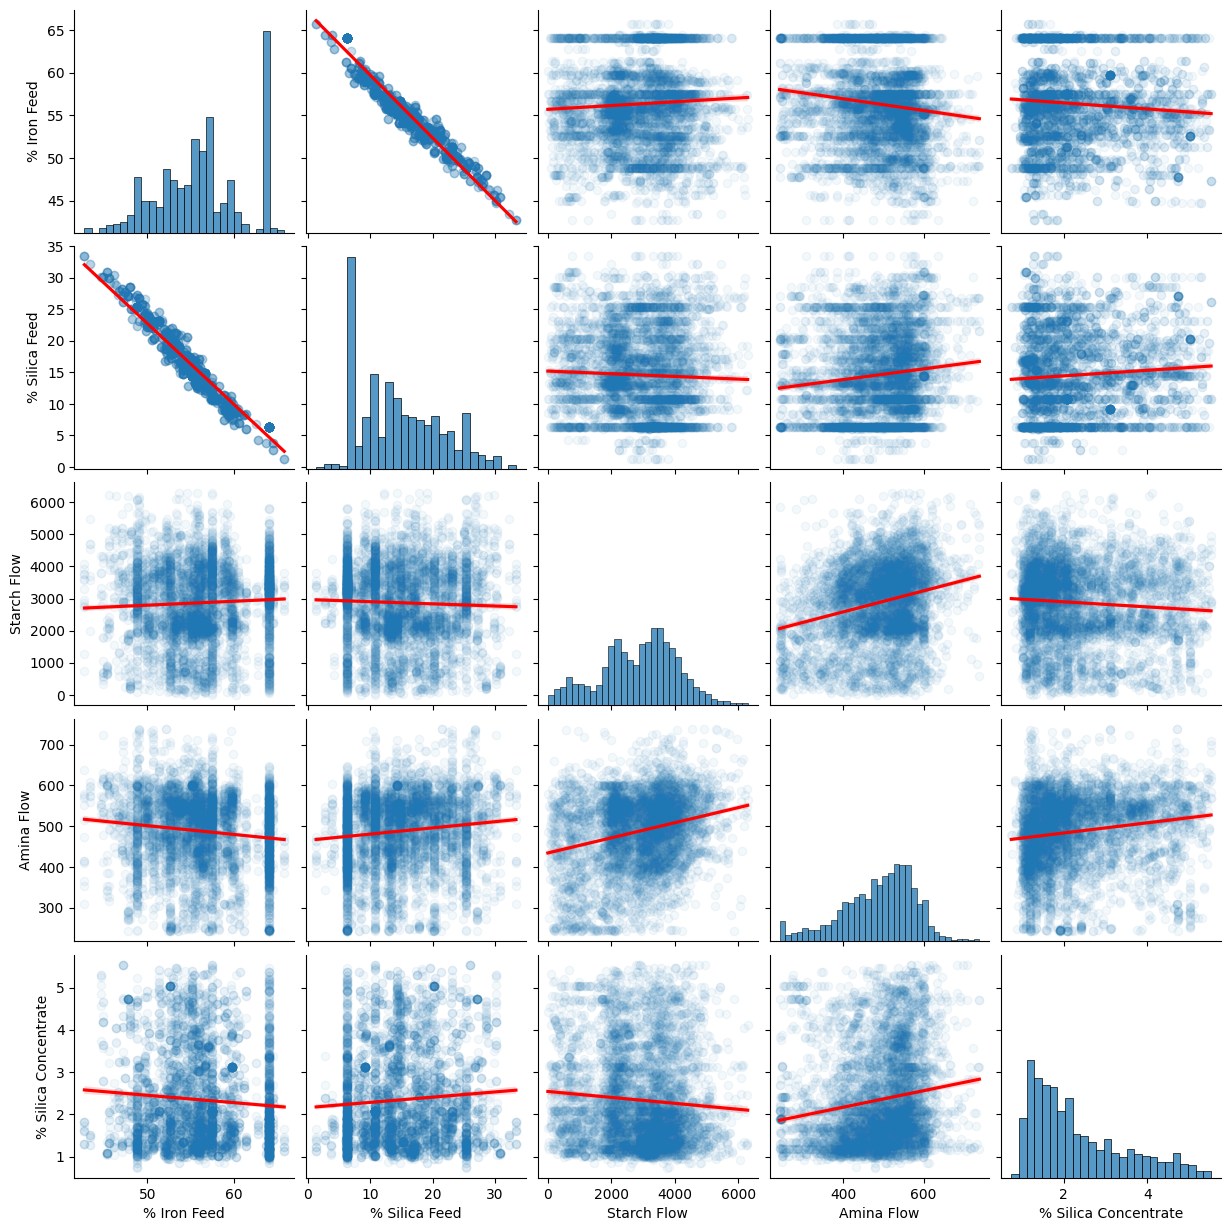

In [10]:
# Graficar solo 5000 filas aleatorias te dará la misma información visual en 2 segundos
sns.pairplot(
    data.sample(5000), # <--- El truco está aquí
    vars=['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', '% Silica Concentrate'],
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.05}, 'line_kws': {'color': 'red'}}
)
plt.show()

There's a weak positive correlation between % Silica Feed and % Silica Concentrate, which is logical.
A weak negative correlation exists between % Iron Feed and % Silica Concentrate, also as expected.

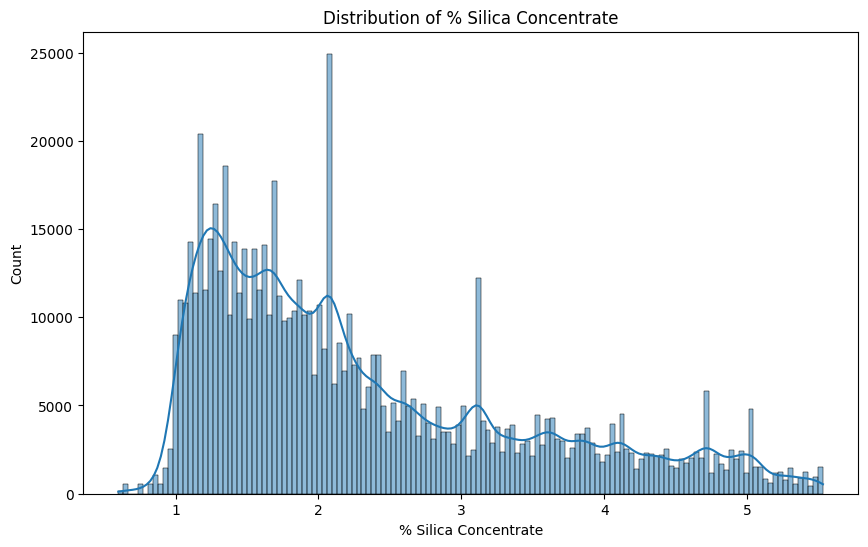

In [11]:
# Distribution of target variable
plt.figure(figsize=(10, 6))
sns.histplot(data[TARGET_VARIABLE], kde=True)
plt.title(f'Distribution of {TARGET_VARIABLE}')
plt.show()

The distribution of % Silica Concentrate is right-skewed, with a peak around 1-2%. Values range from 0.5% to 5%, with most falling between 1-3%. Multiple smaller peaks suggest varied operating conditions. The process appears well-controlled, keeping silica levels low, but there's room for improvement in reducing higher concentrations.


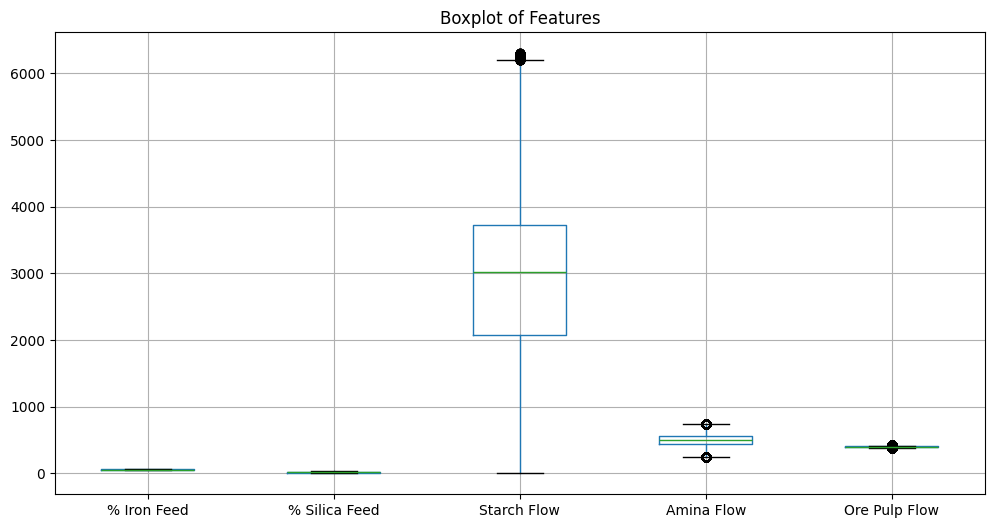

In [12]:
# Boxplot to check for outliers
plt.figure(figsize=(12, 6))
data.boxplot(column=['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow'])
plt.title('Boxplot of Features')
plt.show()

Starch Flow and Amina Flow show the most prominent outliers, particularly on the upper end of their distributions.


###  Data Cleaning (again)

In [13]:
# Action1: Select only the possible features, drop other column

droplist=['% Iron Feed',\
          'Ore Pulp pH','Flotation Column 02 Air Flow',\
          'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',\
          'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',\
          'Flotation Column 07 Air Flow/', 'Flotation Column 01 Level',
          'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 05 Level',
          'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate']

# Create a set of columns to drop that are actually in the DataFrame
columns_to_drop = set(droplist) & set(data.columns)

# Drop the columns
data_2 = data.drop(columns=columns_to_drop)
print(data_2.columns)
# Check the new shape of the DataFrame
print(data_2.shape)

Index(['date', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow',
       'Ore Pulp Density', 'Flotation Column 01 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 04 Level',
       '% Silica Concentrate'],
      dtype='object')
(737453, 10)


# Visualize selected signals

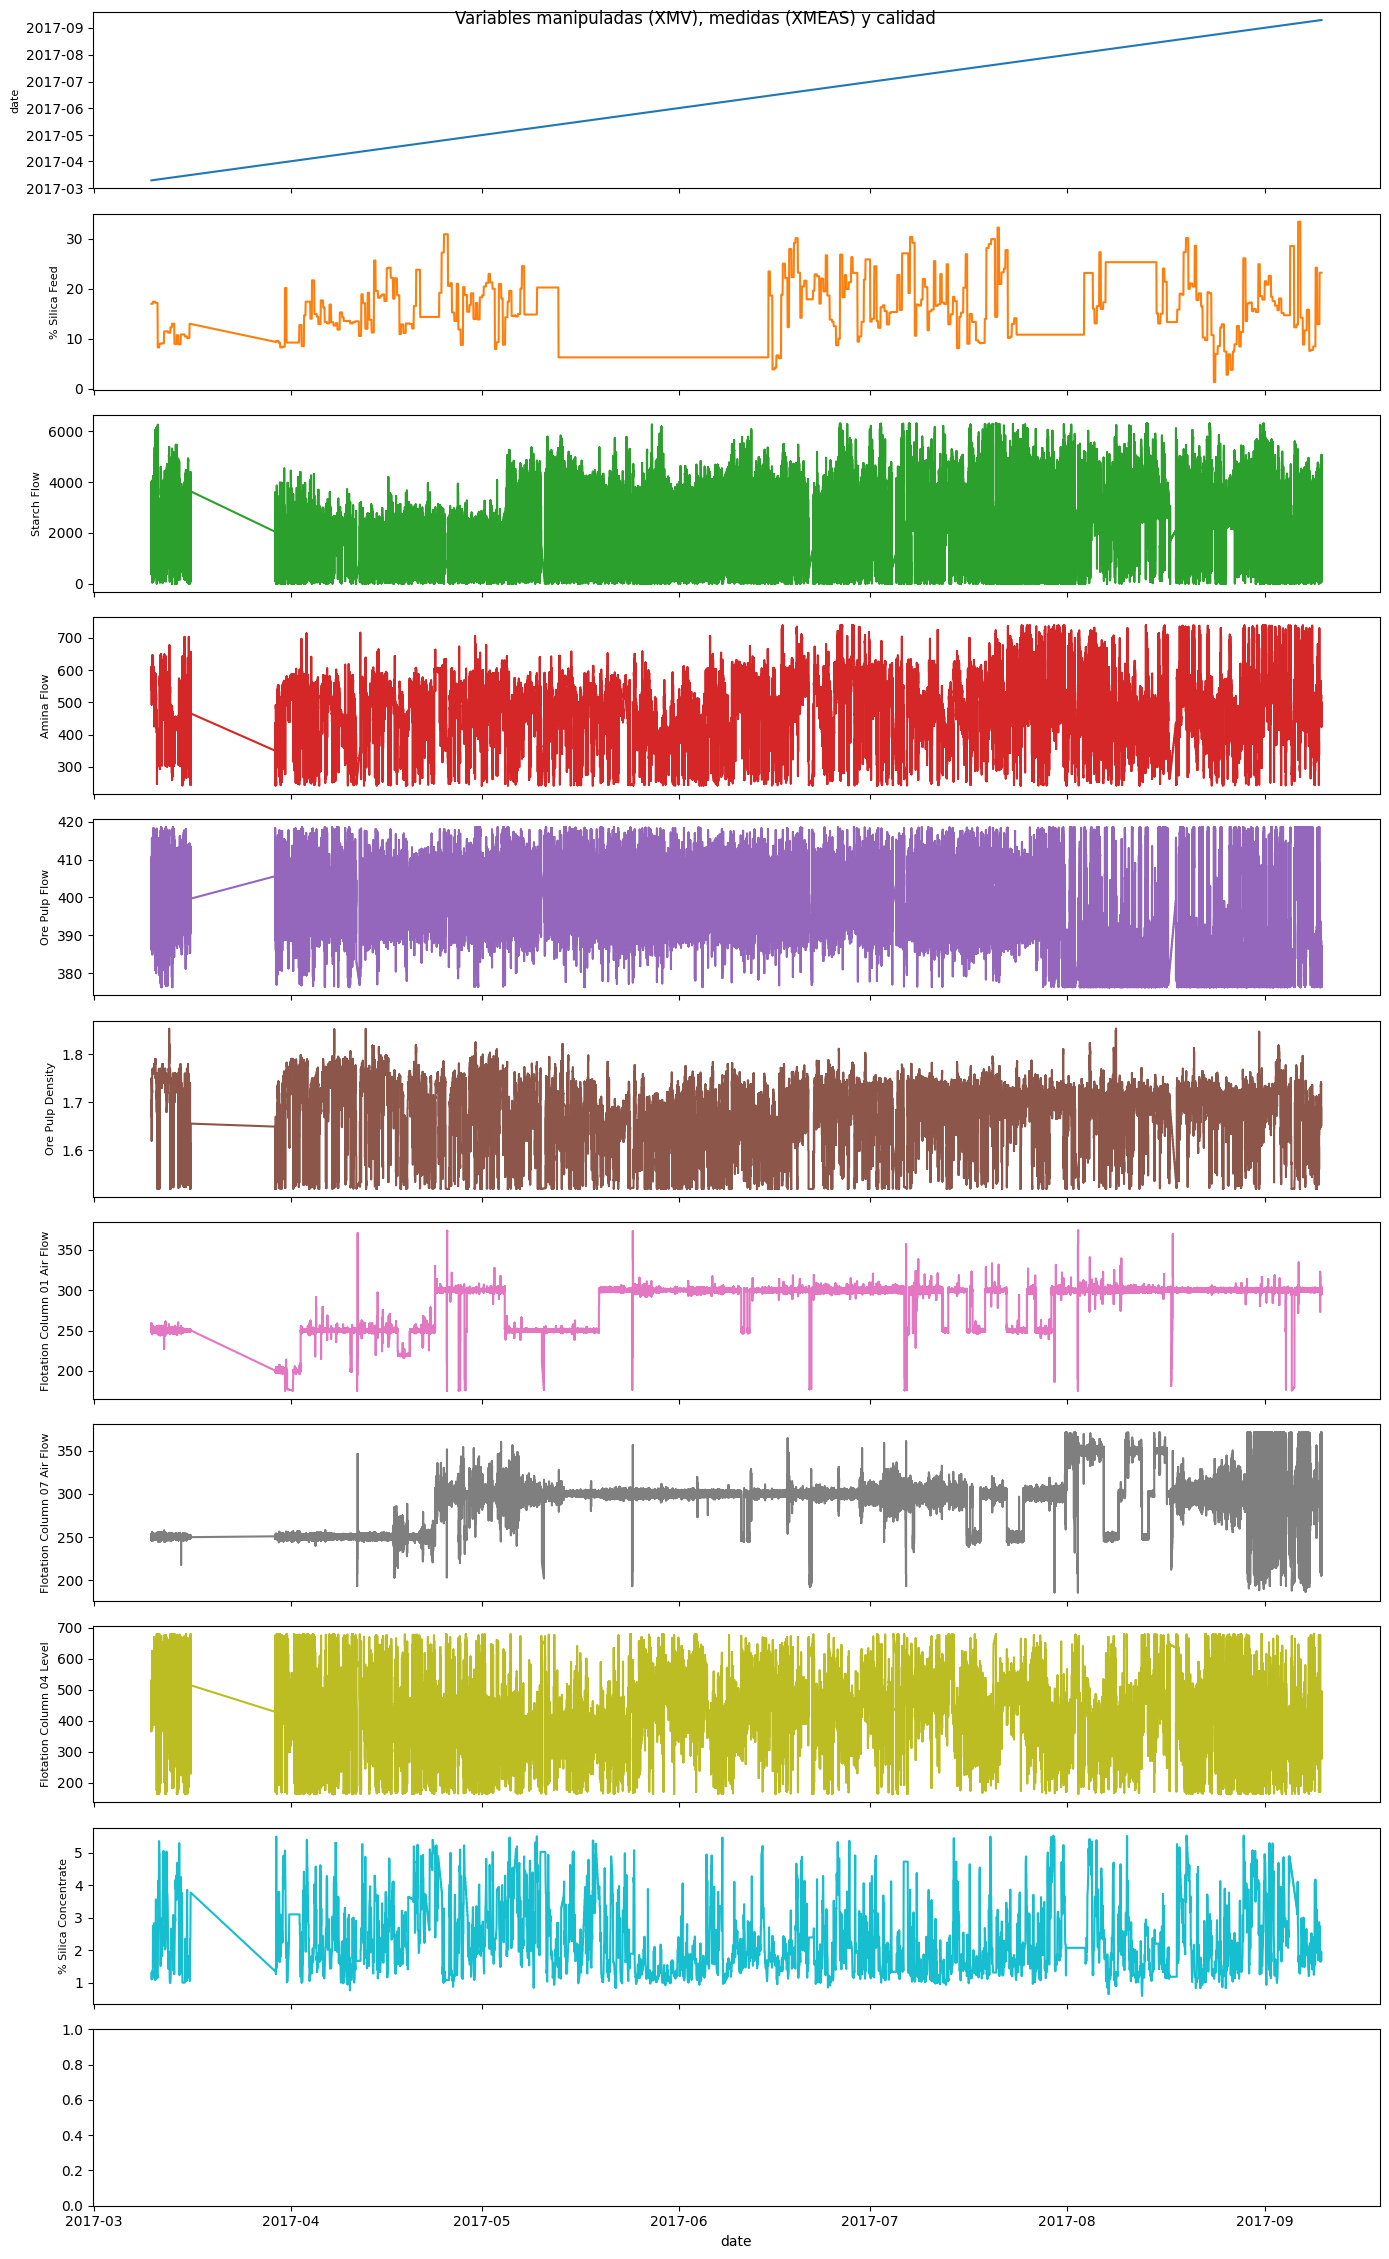

In [14]:
fig, axes = plt.subplots(len(data_2.columns) + 1, 1,
                          figsize=(14, 2.2 * len(data_2.columns) + 1),
                          sharex=True)

todas_vars = data_2.columns 

colores = plt.cm.tab10(np.linspace(0, 1, len(todas_vars)))

for ax, var, color in zip(axes, todas_vars, colores):
    ax.plot(data_2[TIMESTAMP_COL], data_2[var], color=color)
    ax.set_ylabel(var, fontsize=8)

axes[-1].set_xlabel(TIMESTAMP_COL)
plt.suptitle('Variables manipuladas (XMV), medidas (XMEAS) y calidad')
plt.tight_layout()
plt.show()

# Search for days without data for every sensor

In [15]:
import pandas as pd

# 1. Asegurar formato datetime y ordenar cronológicamente
data_2['date'] = pd.to_datetime(data_2['date'])
df = data_2.sort_values('date').reset_index(drop=True)

# 2. Calcular la diferencia de tiempo entre cada fila y la anterior
data_2['date_difference'] = data_2['date'].diff()

# 3. Filtrar los saltos superiores a 3 días (72 horas)
limite_paron = pd.Timedelta(days=3)
huecos = data_2[data_2['date_difference'] > limite_paron]

# 4. Imprimir la información precisa
print(f"Se han encontrado {len(huecos)} parones superiores a 3 días:\n")

for idx in huecos.index:
    fecha_fin_paron = data_2.loc[idx, 'date']
    fecha_inicio_paron = data_2.loc[idx - 1, 'date']
    duracion = data_2.loc[idx, 'date_difference']
    
    print(f"📍 Parón detectado:")
    print(f"   • Último dato válido (Fila {idx-1}): {fecha_inicio_paron}")
    print(f"   • Reanudación datos   (Fila {idx}):   {fecha_fin_paron}")
    print(f"   • Tiempo total a ciegas:           {duracion}\n")

Se han encontrado 1 parones superiores a 3 días:

📍 Parón detectado:
   • Último dato válido (Fila 26813): 2017-03-16 05:00:00
   • Reanudación datos   (Fila 26814):   2017-03-29 12:00:00
   • Tiempo total a ciegas:           13 days 07:00:00



# Se ha detectado un periodo sin modificacion de los datos. Eliminamos y dividimos en bloques, ya que no se pueden aplicar características con un salto temporal intermedio

In [16]:
data_2_bloque_1 = data_2[data_2['date'] <= fecha_inicio_paron].copy()
data_2_bloque_2 = data_2[data_2['date'] >= fecha_fin_paron].copy()

training_data_blocks = [data_2_bloque_1, data_2_bloque_2]

# Looks like silica feed has a long time without varying values, what is suspicious

In [17]:
def dividir_en_bloques_validos(df, rangos_invalidos):
    """
    Divide un DataFrame en bloques continuos, eliminando los rangos de tiempo especificados.
    
    Parámetros:
    - df: DataFrame original (debe tener la columna 'date' en formato datetime)
    - rangos_invalidos: Lista de tuplas con las fechas (start, end) a eliminar
    """
    # 1. Crear una máscara donde todas las filas son válidas por defecto
    mascara_valida = pd.Series(True, index=df.index)
    
    # 2. Marcar como 'False' (inválido) las filas que caen dentro de los sensores muertos
    for inicio, fin in rangos_invalidos:
        en_rango_muerto = (df['date'] >= inicio) & (df['date'] <= fin)
        mascara_valida = mascara_valida & ~en_rango_muerto
        
    # 3. Identificar los bloques continuos válidos
    # Cada vez que pasamos por un tramo inválido, el cumsum() suma 1. 
    # Esto le asigna un "ID" numérico único a cada bloque válido ininterrumpido.
    id_bloques = (~mascara_valida).cumsum()[mascara_valida]
    
    # 4. Agrupar y extraer los bloques
    df_solo_validos = df[mascara_valida]
    bloques_finales = [grupo.reset_index(drop=True) for _, grupo in df_solo_validos.groupby(id_bloques)]
    
    return bloques_finales

In [18]:
frozen_variables = ['% Silica Feed']
for var in frozen_variables:
    frozen = data_2[var].diff().eq(0)
    block = (frozen != frozen.shift()).cumsum()
    runs = df.groupby(block).agg(start=('date', 'first'), end=('date', 'last'),
                                    length=('date', 'size'), val=(var, 'first'))
    print(runs.sort_values('length', ascending=False))
    print(frozen)
    runs_filtrado = runs[runs['length'] > 12960] # Si está parado más de tres días, se elimina ese cacho

    # Convertimos las columnas 'start' y 'end' en una lista de tuplas [(inicio1, fin1), (inicio2, fin2)...]
    lista_rangos_muertos = list(zip(runs_filtrado['start'], runs_filtrado['end']))

    # 2. Creamos una nueva lista para guardar los bloques definitivos
    bloques_finales_limpios = []

    # Definimos el tamaño mínimo que debe tener un bloque para ser útil
    # (Si usas lags de t-1 y medias móviles de 3, necesitas al menos 5 o 10 filas)
    min_filas_requeridas = 15 

    # 3. Iteramos sobre tu división actual
    for bloque in training_data_blocks:
        
        # Dividimos el bloque actual usando la función que creamos antes
        sub_bloques = dividir_en_bloques_validos(bloque, lista_rangos_muertos)
        
        # Filtramos y guardamos solo los sub-bloques que tengan un tamaño aceptable
        for sub_b in sub_bloques:
            if len(sub_b) >= min_filas_requeridas:
                bloques_finales_limpios.append(sub_b)

print(f"De {len(training_data_blocks)} macro-bloques originales...")
print(f"Se han generado {len(bloques_finales_limpios)} sub-bloques 100% limpios y continuos.")

                            start                 end  length    val
% Silica Feed                                                       
238           2017-05-13 01:00:00 2017-06-15 00:00:00  142559   6.26
454           2017-07-24 01:00:00 2017-08-03 15:00:00   45899  10.80
470           2017-08-07 01:00:00 2017-08-15 00:00:00   34559  25.31
236           2017-05-09 16:00:00 2017-05-13 00:00:00   14579  20.24
154           2017-04-21 07:00:00 2017-04-24 06:00:00   12959  14.35
...                           ...                 ...     ...    ...
571           2017-09-02 01:00:00 2017-09-02 01:00:00       1  18.37
569           2017-09-01 16:00:00 2017-09-01 16:00:00       1  22.56
567           2017-09-01 07:00:00 2017-09-01 07:00:00       1  20.81
257           2017-06-18 01:00:00 2017-06-18 01:00:00       1  12.31
29            2017-03-15 07:00:00 2017-03-15 07:00:00       1  10.44

[612 rows x 4 columns]
0         False
1          True
2          True
3          True
4          True

# Feature engineering

In [19]:
def construir_features(df, variables_entrada, usar_lags=True, n_lags=3,
                        espaciado_lags='consecutivo', base_potencia=2,
                        usar_rolling_mean=False, ventana_mean=5,
                        usar_rolling_std=False, ventana_std=5,
                        usar_diff=False, consider_target_variable_ft=False):
    df_out = df.copy()
    columnas_features = list(variables_entrada)

    lista_lags = list(range(1, n_lags + 1))

    # Acumulamos las columnas nuevas en un diccionario y las unimos con UN solo concat al
    # final, en vez de insertarlas una a una con df_out[col] = ... . Insertar columna a
    # columna fragmenta el DataFrame internamente (pandas avisa con PerformanceWarning) y
    # es notablemente más lento cuando esta función se llama muchas veces seguidas -- como
    # ocurre en construir_features_multi_sim, que la invoca una vez POR CADA simulación.
    nuevas_columnas = {}
    for var in variables_entrada:
        if not consider_target_variable_ft and var == TARGET_VARIABLE:
            continue 
        if var == TIMESTAMP_COL:
            continue

        if usar_lags:
            for lag in lista_lags:
                col = f'{var}_lag_{lag}'
                nuevas_columnas[col] = df_out[var].shift(lag)
                columnas_features.append(col)
        if usar_rolling_mean:
            col = f'{var}_roll_mean_{ventana_mean}'
            nuevas_columnas[col] = df_out[var].shift(1).rolling(window=ventana_mean).mean()
            columnas_features.append(col)
        if usar_rolling_std:
            col = f'{var}_roll_std_{ventana_std}'
            nuevas_columnas[col] = df_out[var].shift(1).rolling(window=ventana_std).std()
            columnas_features.append(col)
        if usar_diff:
            col = f'{var}_diff'
            nuevas_columnas[col] = df_out[var].diff()
            columnas_features.append(col)

    df_out = pd.concat([df_out, pd.DataFrame(nuevas_columnas, index=df_out.index)], axis=1)

    return df_out, columnas_features

In [20]:
ft_training_data_blocks = []

# For posterior forecasting
horizonte_prediccion = 15  # 15 muestras * 20 segundos = 300 segundos (5 minutos)

for block in bloques_finales_limpios:
    df_feat, cols_feat = construir_features(
        block, block.columns,
        usar_lags=False, n_lags=1, espaciado_lags='consecutivo',
        usar_rolling_mean=False, ventana_mean=3,
        usar_rolling_std=False, 
        usar_diff=True, consider_target_variable_ft=False
    )
    df_feat['Target_Silica_5min'] = df_feat['% Silica Concentrate'].shift(-horizonte_prediccion)
    df_feat = df_feat.dropna().reset_index(drop=True)
    df_feat.head()
    ft_training_data_blocks.append(df_feat)
# Join data from both blocks in the same dataframe
# Join data from both blocks in the same dataframe
df_feat = pd.concat(ft_training_data_blocks, ignore_index=True)

# (Opcional) Comprobación rápida para ver cómo ha quedado
print(f"Número de bloques unidos: {len(ft_training_data_blocks)}")
print(f"Dimensiones del dataset final listo para XGBoost: {df_feat.shape}")


Número de bloques unidos: 5
Dimensiones del dataset final listo para XGBoost: (499772, 21)


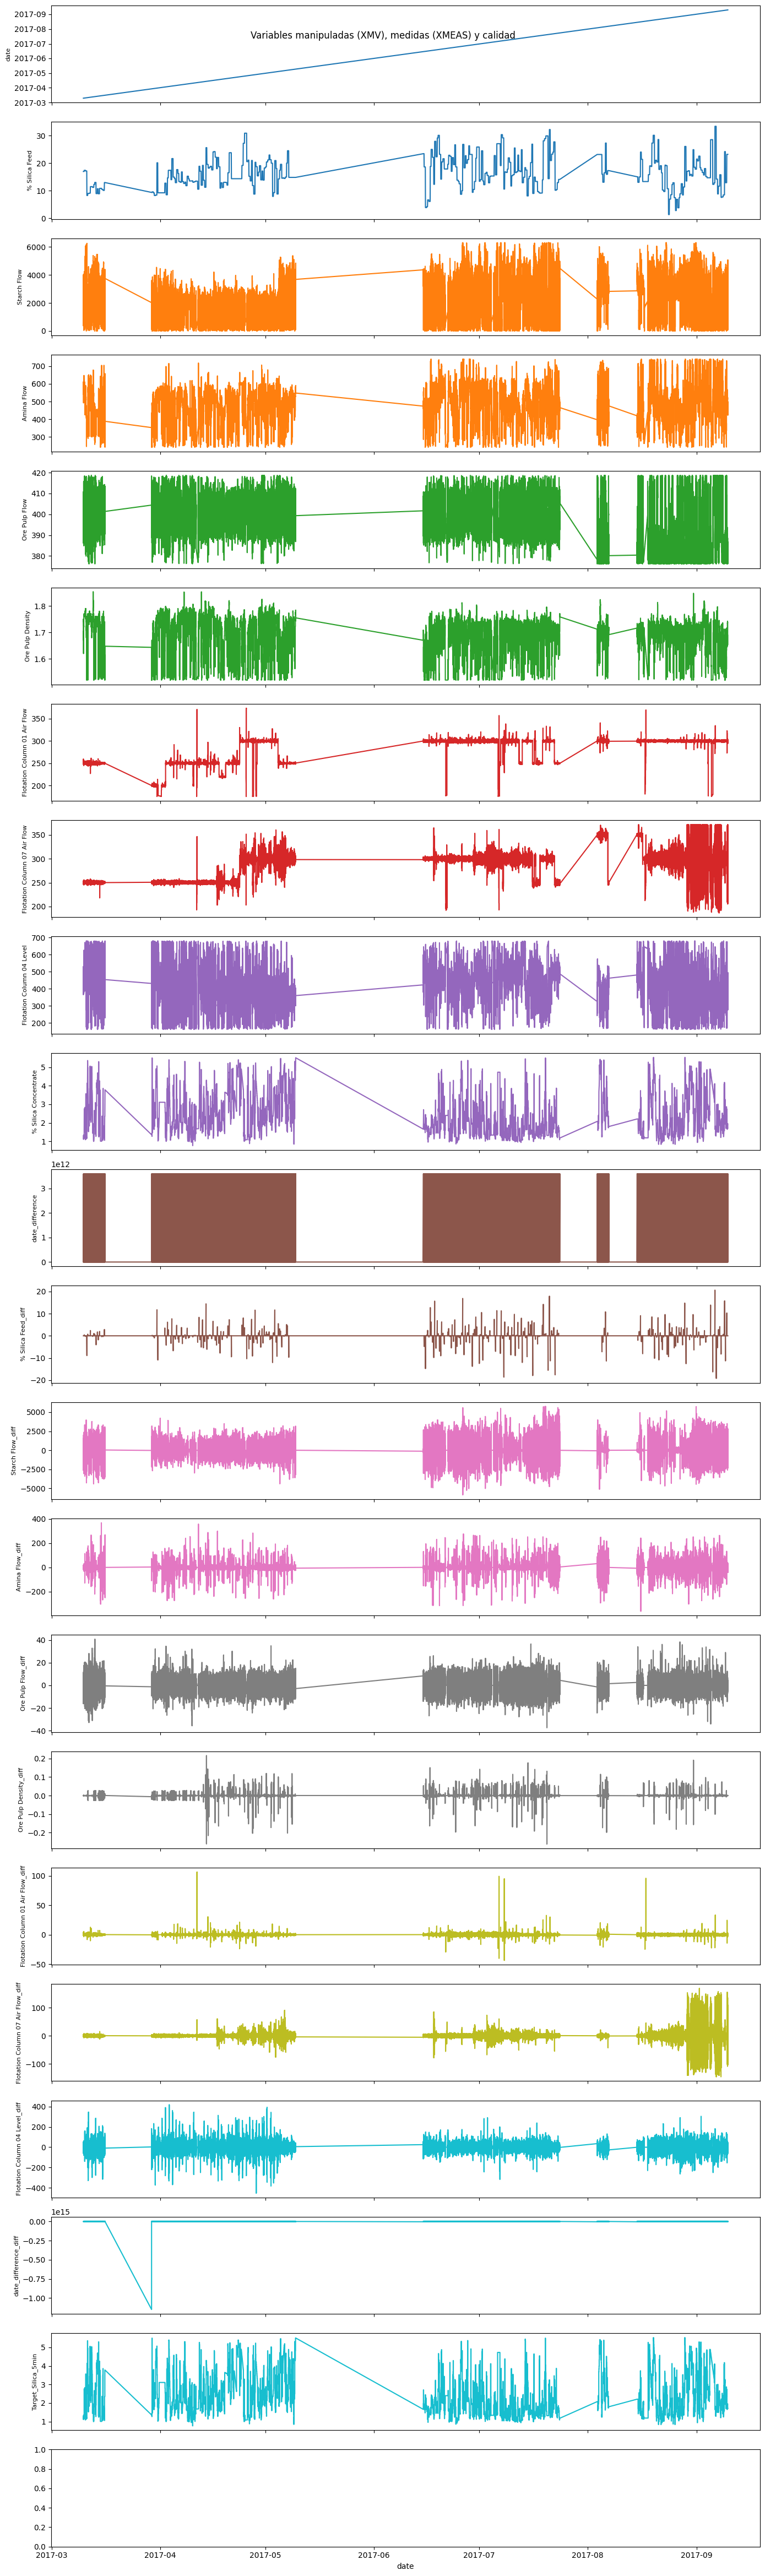

In [21]:
fig, axes = plt.subplots(len(df_feat.columns) + 1, 1,
                          figsize=(14, 2.2 * len(df_feat.columns) + 1),
                          sharex=True)

todas_vars = df_feat.columns 

colores = plt.cm.tab10(np.linspace(0, 1, len(todas_vars)))

for ax, var, color in zip(axes, todas_vars, colores):
    ax.plot(df_feat[TIMESTAMP_COL], df_feat[var], color=color)
    ax.set_ylabel(var, fontsize=8)

axes[-1].set_xlabel(TIMESTAMP_COL)
plt.suptitle('Variables manipuladas (XMV), medidas (XMEAS) y calidad')
plt.tight_layout()
plt.show()

###  Modeling

In [31]:
df_feat_forecast = df_feat.copy()

df_feat=df_feat.drop([var for var in df_feat.head() if TIMESTAMP_COL in var or 'Target_' in var],axis=1)

print(df_feat_forecast.head())

## Split data to training set and test set 

X=df_feat.drop('% Silica Concentrate',axis=1)

y=df_feat['% Silica Concentrate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Definimos la nueva variable objetivo
TARGET_FORECAST = 'Target_Silica_5min'

# Eliminamos la fecha, la sílice objetivo y, MUY IMPORTANTE, la sílice del presente
columnas_a_excluir = ['date', TARGET_FORECAST, '% Silica Concentrate', 'date_difference']
variables_x_forecast = [col for col in df_feat_forecast.columns if col not in columnas_a_excluir]

X_forecast = df_feat_forecast[variables_x_forecast]
y_forecast = df_feat_forecast[TARGET_FORECAST]

# Aquí deberías aplicar tu train_test_split respetando el orden temporal (shuffle=False)
from sklearn.model_selection import train_test_split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_forecast, y_forecast, test_size=0.2, shuffle=False
)

   % Silica Feed  Starch Flow  Amina Flow  Ore Pulp Flow  Ore Pulp Density  \
0          16.98      3043.46     568.054        399.668              1.74   
1          16.98      3047.36     568.665        397.939              1.74   
2          16.98      3033.69     558.167        400.254              1.74   
3          16.98      3079.10     564.697        396.533              1.74   
4          16.98      3127.79     566.467        392.900              1.74   

   Flotation Column 01 Air Flow  Flotation Column 07 Air Flow  \
0                       249.741                       248.071   
1                       249.917                       251.147   
2                       250.203                       248.928   
3                       250.730                       251.873   
4                       250.313                       253.477   

   Flotation Column 04 Level  % Silica Concentrate  % Silica Feed_diff  \
0                    449.688                  1.31                

KeyError: 'Target_Silica_5min'

In [ ]:
print(y.shape)
print(y_train.shape)
print(y_test.shape)

(499772,)
(399817,)
(99955,)


# Analyse train and test distribution

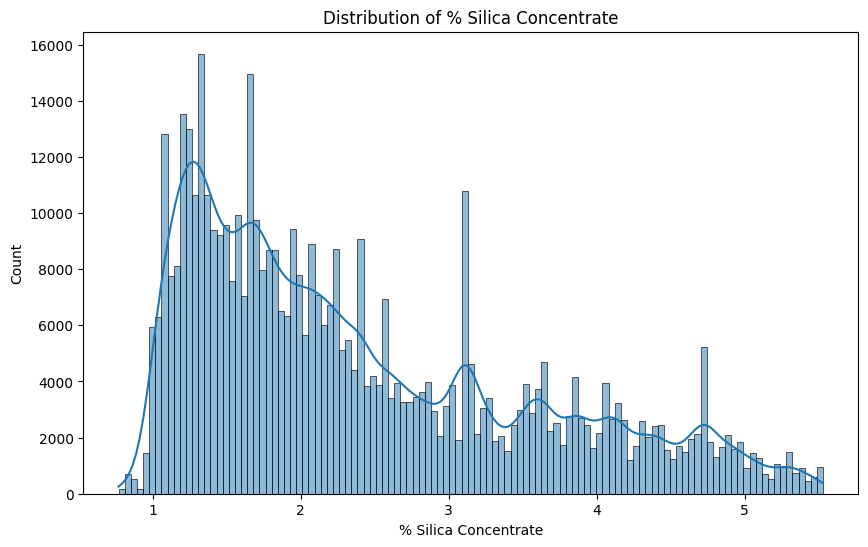

In [ ]:
# Distribution of target variable
plt.figure(figsize=(10, 6))
sns.histplot(df_feat[TARGET_VARIABLE], kde=True)
plt.title(f'Distribution of {TARGET_VARIABLE}')
plt.show()

In [ ]:
def construir_features(df, variables_entrada, usar_lags=True, n_lags=3,
                        espaciado_lags='consecutivo', base_potencia=2,
                        usar_rolling_mean=False, ventana_mean=5,
                        usar_rolling_std=False, ventana_std=5,
                        usar_diff=False, consider_target_variable_ft=False):
    df_out = df.copy()
    columnas_features = list(variables_entrada)

    lista_lags = list(range(1, n_lags + 1))

    # Acumulamos las columnas nuevas en un diccionario y las unimos con UN solo concat al
    # final, en vez de insertarlas una a una con df_out[col] = ... . Insertar columna a
    # columna fragmenta el DataFrame internamente (pandas avisa con PerformanceWarning) y
    # es notablemente más lento cuando esta función se llama muchas veces seguidas -- como
    # ocurre en construir_features_multi_sim, que la invoca una vez POR CADA simulación.
    nuevas_columnas = {}
    for var in variables_entrada:
        if not consider_target_variable_ft and var == TARGET_VARIABLE:
            continue 

        if usar_lags:
            for lag in lista_lags:
                col = f'{var}_lag_{lag}'
                nuevas_columnas[col] = df_out[var].shift(lag)
                columnas_features.append(col)
        if usar_rolling_mean:
            col = f'{var}_roll_mean_{ventana_mean}'
            nuevas_columnas[col] = df_out[var].shift(1).rolling(window=ventana_mean).mean()
            columnas_features.append(col)
        if usar_rolling_std:
            col = f'{var}_roll_std_{ventana_std}'
            nuevas_columnas[col] = df_out[var].shift(1).rolling(window=ventana_std).std()
            columnas_features.append(col)
        if usar_diff:
            col = f'{var}_diff'
            nuevas_columnas[col] = df_out[var].diff()
            columnas_features.append(col)

    df_out = pd.concat([df_out, pd.DataFrame(nuevas_columnas, index=df_out.index)], axis=1)

    return df_out, columnas_features

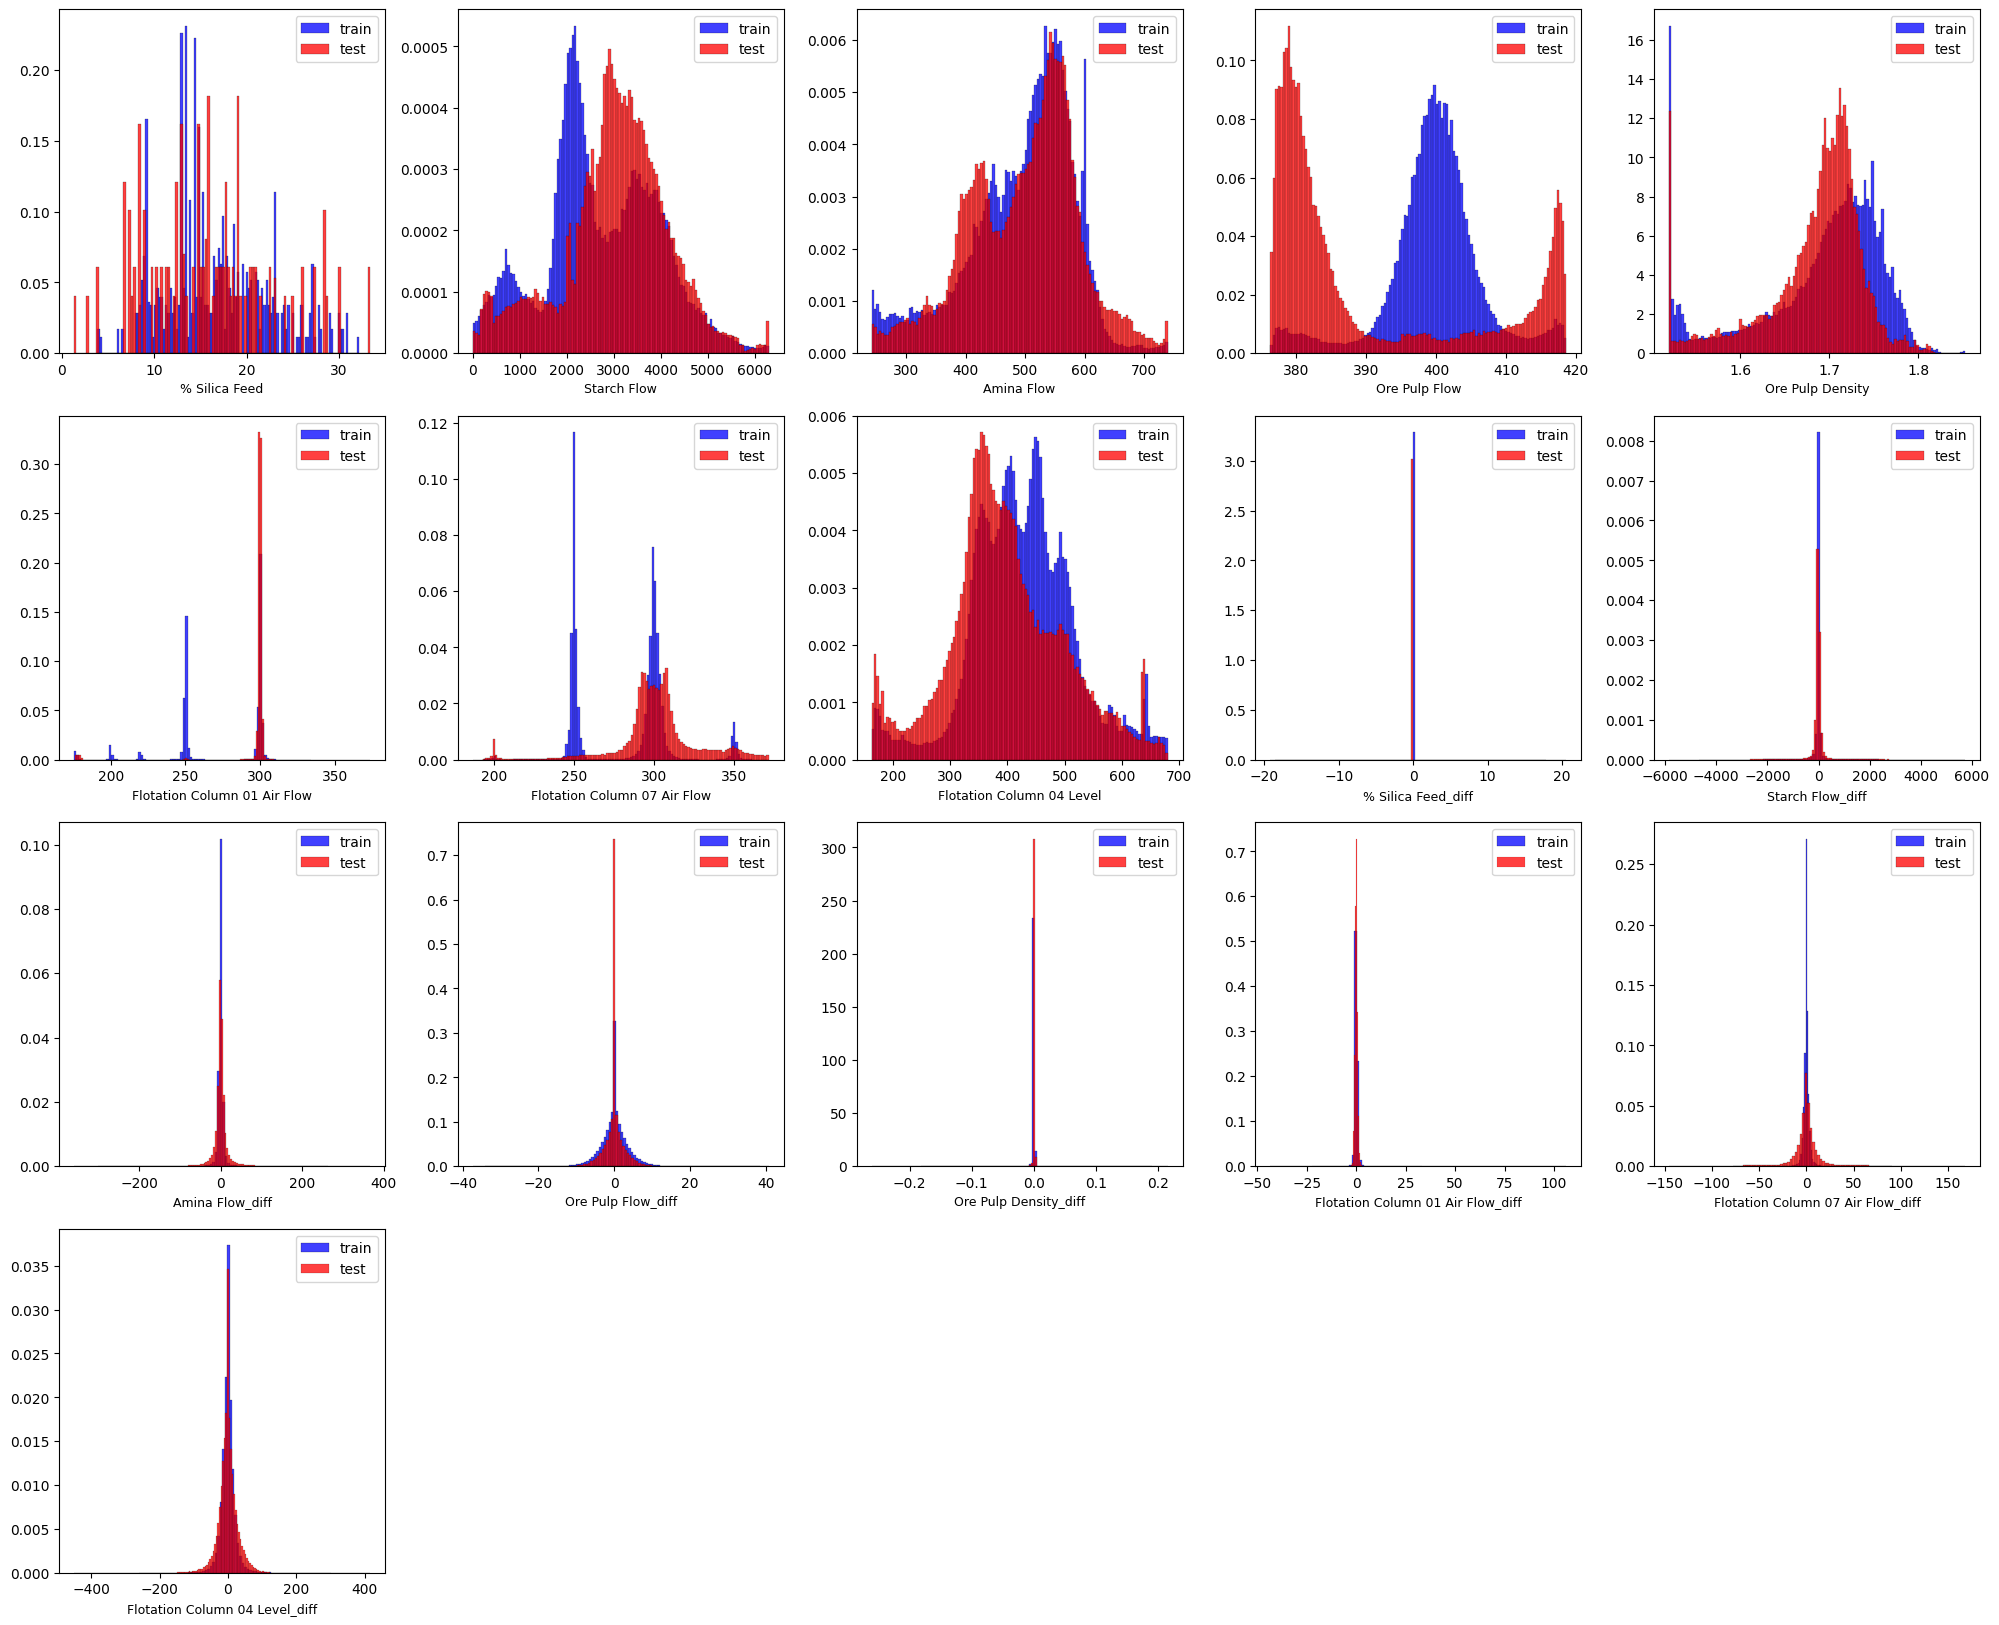

In [ ]:
# Filtramos las características que queremos dibujar antes de empezar
features_a_dibujar = [f for f in df_feat.columns if '_lag_' not in f and f != TARGET_VARIABLE]

# Creamos la figura y los ejes de forma limpia (ej. panel de 5x5)
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente (0 a 24)

for i, feature in enumerate(features_a_dibujar):
    if i >= 25: 
        break # Por si tienes más de 25 variables y te quedas sin huecos en el 5x5
        
    ax = axes[i]
    
    # 💡 APAGAMOS el KDE (kde=False) para evitar el MemoryError
    sns.histplot(X_train[feature], color="blue", kde=False, bins=120, label='train', stat="density", ax=ax)
    sns.histplot(X_test[feature], color="red", kde=False, bins=120, label='test', stat="density", ax=ax)
    
    ax.set_ylabel("")
    ax.set_xlabel(feature, fontsize=9)
    ax.legend()

# Ocultar los subplots vacíos si tienes menos de 25 variables
for j in range(i + 1, 25):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Train model

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 3. Inicializar y entrenar el modelo XGBoost
# n_estimators son los árboles, learning_rate controla qué tan rápido aprende
modelo_xgb = xgb.XGBRegressor(
    n_estimators=1000,          # Subimos el límite de árboles (el early stopping lo frenará)
    learning_rate=0.03,         # Aprendizaje más lento para que sea más preciso
    # max_depth=7,                # Aumentamos (por defecto es 6). Le permite buscar patrones más complejos para los picos altos.
    # min_child_weight=1,         # Le damos permiso para aprender de grupos pequeños de datos (como los picos raros).
    # subsample=0.8,              # Usa el 80% de los datos en cada árbol para evitar memorizar
    # colsample_bytree=0.8,       # Usa el 80% de las columnas en cada árbol
    # early_stopping_rounds=40,
    random_state=42
)


In [ ]:
# 1. Configuramos la validación cruzada en 5 cortes temporales
tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []
r2_scores = []

print("Iniciando Validación Cruzada Temporal (5 Pliegues)...\n")

# 3. Bucle de entrenamiento a través del tiempo
for fold, (train_index, test_index) in enumerate(tscv.split(X_forecast)):
    
    # Separamos en Train y Test respetando la inercia temporal
    X_train_fold = X_forecast.iloc[train_index]
    y_train_fold = y_forecast.iloc[train_index]
    X_test_fold = X_forecast.iloc[test_index]
    y_test_fold = y_forecast.iloc[test_index]
    
    # Entrenamos en este pliegue
    modelo_xgb.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)],
        verbose=False
    )
    
    # Evaluamos el futuro de este pliegue
    predicciones = modelo_xgb.predict(X_test_fold)
    rmse = mean_squared_error(y_test_fold, predicciones, squared=False)
    r2 = r2_score(y_test_fold, predicciones)
    
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    
    print(f"Pliegue {fold + 1} | Árbol óptimo: {modelo_xgb.best_iteration:3d} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

# 4. Resumen final de rendimiento
print("-" * 55)
print(f"RENDIMIENTO MEDIO ESPERADO EN PRODUCCIÓN:")
print(f"RMSE Promedio: {np.mean(rmse_scores):.4f}")
print(f"R² Promedio:   {np.mean(r2_scores):.4f}")
print("-" * 55)

Iniciando Validación Cruzada Temporal (5 Pliegues)...



ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:date_difference: timedelta64[ns], date_difference_diff: timedelta64[ns]

In [ ]:
modelo_xgb.fit(X_train, y_train)

# 4. Evaluar el error básico
pred_train = modelo_xgb.predict(X_train)
pred_test = modelo_xgb.predict(X_test)

# 2. Calcular métricas para el conjunto de Entrenamiento (Train)
rmse_train = mean_squared_error(y_train, pred_train)
mae_train = mean_absolute_error(y_train, pred_train)
r2_train = r2_score(y_train, pred_train)

# 3. Calcular métricas para el conjunto de Prueba (Test)
rmse_test = mean_squared_error(y_test, pred_test)
mae_test = mean_absolute_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)

# 4. Imprimir el reporte comparativo
print("=" * 45)
print("   REPORTE DE RENDIMIENTO DEL MODELO XGBOOST")
print("=" * 45)
print("MÉTRICAS EN ENTRENAMIENTO (Train):")
print(f"  • RMSE (Error Cuadrático Medio): {rmse_train:.4f}")
print(f"  • MAE  (Error Absoluto Medio):   {mae_train:.4f}")
print(f"  • R²   (Varianza Explicada):     {r2_train:.4f}")
print("-" * 45)
print("MÉTRICAS EN PRUEBA (Test - Datos nuevos):")
print(f"  • RMSE (Error Cuadrático Medio): {rmse_test:.4f}")
print(f"  • MAE  (Error Absoluto Medio):   {mae_test:.4f}")
print(f"  • R²   (Varianza Explicada):     {r2_test:.4f}")
print("=" * 45)

# 5. La prueba del algodón: ¿Qué variables son realmente importantes para XGBoost?
plt.figure(figsize=(10, 6))
xgb.plot_importance(modelo_xgb, importance_type='gain', max_num_features=15, 
                    color='#1f77b4', edgecolor='black')

plt.title('Top 15 Variables más Importantes (Ganancia de Información)', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Sensores / Features', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Definir los conjuntos de evaluación para monitorizar el overfitting
# validation_0 será Train, validation_1 será Test
eval_set = [(X_train, y_train), (X_test, y_test)]

# 3. Entrenar el modelo
print("Iniciando entrenamiento y monitorizando errores...")
modelo_xgb.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False # Cambia a True si quieres ver en la consola cómo baja el error árbol a árbol
)

# 4. Extraer el historial de errores (RMSE)
resultados = modelo_xgb.evals_result()
errores_train = resultados['validation_0']['rmse']
errores_test = resultados['validation_1']['rmse']

# Saber exactamente en qué iteración alcanzó su máxima precisión real
n_arboles_optimo = modelo_xgb.best_iteration
print(f"¡Entrenamiento finalizado! El modelo óptimo se alcanzó en el árbol: {n_arboles_optimo}")

# 5. Graficar las curvas de aprendizaje (La prueba de fuego)
plt.figure(figsize=(10, 6))

# Línea de Train (Azul)
plt.plot(errores_train, label='Error Train (Conoce las respuestas)', color='#1f77b4', linewidth=2)
# Línea de Test (Rojo)
plt.plot(errores_test, label='Error Test (Datos jamás vistos)', color='#d62728', linewidth=2)

# Marcamos el punto exacto donde se activó el freno de emergencia
plt.axvline(n_arboles_optimo, color='gray', linestyle='--', 
            label=f'Punto Óptimo (Árbol {n_arboles_optimo})')

plt.title('Curva de Aprendizaje de XGBoost: Detección de Overfitting', fontsize=14)
plt.xlabel('Número de Árboles Construidos (Iteraciones)', fontsize=12)
plt.ylabel('Error (RMSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_muestras = 100

# Es importante resetear el índice de y_test para que se alinee correctamente 
# con el array de predicciones, evitando que Matplotlib dibuje líneas caóticas.
y_test_plot = y_test.reset_index(drop=True)

# Creamos una figura con dos subgráficos (uno arriba y otro abajo)
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# ---------------------------------------------------------
# GRÁFICA 1: Señal Real vs Predicción (Línea de tiempo/muestras)
# ---------------------------------------------------------
# Dibujamos los datos reales en azul
axes[0].plot(y_test_plot[:n_muestras], label='Real (% Silica Concentrate)', color='#1f77b4', linewidth=1.5)

# Dibujamos las predicciones en naranja (con un poco de transparencia para ver si se solapan bien)
axes[0].plot(pred_test[:n_muestras], label='Predicción (XGBoost)', color='#ff7f0e', alpha=0.8, linewidth=1.5)

axes[0].set_title('Comparación de la Señal: Real vs Predicción (XGBoost)', fontsize=14)
axes[0].set_ylabel('% Silica Concentrate')
axes[0].set_xlabel('Muestras (Test)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 💡 TRUCO: Si tu set de test tiene miles de puntos, la gráfica de arriba se verá como un borrón. 
# Descomenta la siguiente línea para hacer "zoom" en las primeras 200 muestras y ver bien el ajuste:
# axes[0].set_xlim(0, 200) 


# ---------------------------------------------------------
# GRÁFICA 2: Dispersión (Gráfico Y vs Ŷ) - Ideal para Machine Learning
# ---------------------------------------------------------
axes[1].scatter(y_test_plot, pred_test, alpha=0.3, color='teal', edgecolor='k')

# Dibujamos la línea roja diagonal de "Perfección" (y = x)
min_val = min(y_test_plot.min(), pred_test.min())
max_val = max(y_test_plot.max(), pred_test.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ajuste Perfecto (Real = Predicción)')

axes[1].set_title('Gráfico de Dispersión: Valores Reales vs Predichos', fontsize=14)
axes[1].set_xlabel('Valor Real (% Silica Concentrate)')
axes[1].set_ylabel('Valor Predicho por XGBoost')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de residuos

In [ ]:
# 1. Calcular los residuos usando tus datos de Test
# Asegúrate de haber ejecutado antes: pred_test = modelo_xgb.predict(X_test)
residuos = y_test - pred_test

# 2. Crear el lienzo para las dos gráficas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# GRÁFICA 1: Residuos vs. Valores Reales
# ---------------------------------------------------------
sns.scatterplot(x=y_test, y=residuos, alpha=0.3, ax=axes[0], color='teal', edgecolor='k')

# Línea roja en el cero absoluto (El error perfecto)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)

axes[0].set_title('1. Residuos frente a la Realidad', fontsize=14)
axes[0].set_xlabel('Valor Real (% Silica Concentrate)', fontsize=12)
axes[0].set_ylabel('Error / Residuo (Real - Predicho)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# GRÁFICA 2: Distribución (Histograma) de los errores
# ---------------------------------------------------------
sns.histplot(residuos, kde=True, bins=100, ax=axes[1], color='#ff7f0e', stat='density')

# Línea roja en el cero absoluto
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)

axes[1].set_title('2. Distribución de los Errores', fontsize=14)
axes[1].set_xlabel('Magnitud del Error', fontsize=12)
axes[1].set_ylabel('Densidad (Frecuencia)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La pendiente positiva indica que el modelo es conservador, de tal forma que sobrepredice con respecto al valor promedio de 3%

# Forecasting a 15 minutos